In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

In [35]:
termpicks = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/TermPicks/TermPicks_V2/TermPicks_V2.shp')
N79_autoterm = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/AutoTerm/GID101.shp')
N79_autoterm_lobe2 = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/AutoTerm/GID100.shp')
nsidc = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/NSIDC Termini/glacier_termini_v01.0.shp')
# sofia_termini = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/Sofia ZI Termini/QGIS_GrIMPtraces_sofia.shp')

## NSIDC

All data are manually traced from GrIMP Sentinel-1 imagery.

,Image_ID,Image_Tile,SourceDate,Quality_Fl,Glacier_ID,geometry,Year,Month
0,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_170_004267,2015-01-21,0,106,"LINESTRING (470860.626 -1011118.049, 470686.00...",2015,1
1,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_170_004267,2015-01-21,0,211,"LINESTRING (489603.36 -1040136.023, 489603.36 ...",2015,1
2,SEN1_NSIDC_0723_V2_20150206_20150217,S1A_170_004617,2015-02-14,0,106,"LINESTRING (460558.724 -1009225.614, 460907.97...",2015,2
3,SEN1_NSIDC_0723_V2_20150206_20150217,S1A_170_004617,2015-02-14,0,211,"LINESTRING (484270.086 -1008125.13, 484333.586...",2015,2
4,SEN1_NSIDC_0723_V2_20150606_20150617,S1A_170_006367,2015-06-14,0,106,"LINESTRING (461223.094 -1010479.345, 461466.51...",2015,6
...,...,...,...,...,...,...,...,...
149,SEN1_NSIDC_0723_V4_20210902_20210907,S1B_170_028546,2021-09-04,0,211,"LINESTRING (484481.753 -1008813.048, 484481.75...",2021,9
150,SEN1_NSIDC_0723_V4_20211002_20211007,S1A_170_039967,2021-10-04,0,106,"LINESTRING (466517.153 -1019068.134, 466834.65...",2021,10
151,SEN1_NSIDC_0723_V4_20211002_20211007,S1A_170_039967,2021-10-04,0,211,"LINESTRING (484534.67 -1008844.798, 484460.586...",2021,10
152,SEN1_NSIDC_0723_V4_20211201_20211206,S1A_170_040842,2021-12-03,0,106,"LINESTRING (466485.403 -1019046.967, 466644.15...",2021,12


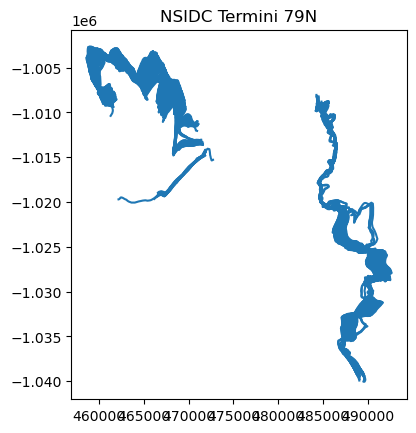

In [3]:
N79_nsidc = nsidc[nsidc['Glacier_ID'] == 106]
N79_nsidc = pd.merge(N79_nsidc, nsidc[nsidc['Glacier_ID'] == 211], how='outer')

# Add Month and Year columns to dataframe
N79_nsidc['Year'] = pd.to_datetime(N79_nsidc['SourceDate']).dt.year
N79_nsidc['Month'] = pd.to_datetime(N79_nsidc['SourceDate']).dt.month

N79_nsidc.plot()
plt.title("NSIDC Termini 79N")
N79_nsidc

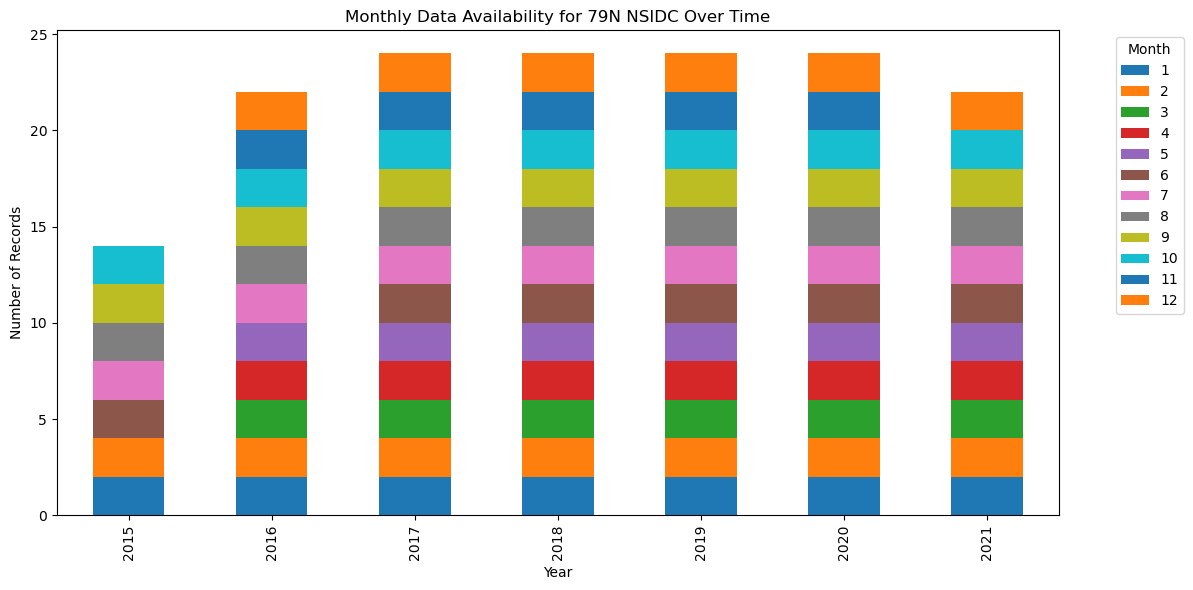

In [4]:
monthly_counts = N79_nsidc.groupby(['Year', 'Month']).size().unstack()

monthly_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.title('Monthly Data Availability for 79N NSIDC Over Time')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## AutoTerm

Termini are automatically digitized from Sentinel-2, Sentinel-1, and Landsat-8 imagery using a deep learning algorithm

,Date,Glacier ID,Satellite,Uncertaint,geometry,Year,Month
0,1984-05-06,GID100,Landsat5,807.417048,"LINESTRING Z (-20.21708 79.88677 0, -20.21659 ...",1984,5
1,1985-05-02,GID100,Landsat5,807.417048,"LINESTRING Z (-20.55843 79.7307 0, -20.55818 7...",1985,5
2,1985-05-02,GID101,Landsat5,1134.815254,"LINESTRING Z (-19.3847 79.6769 0, -19.3847 79....",1985,5
3,1985-05-07,GID100,Landsat5,807.417048,"LINESTRING Z (-20.55843 79.73118 0, -20.55818 ...",1985,5
4,1985-05-07,GID101,Landsat5,1134.815254,"LINESTRING Z (-19.52682 79.67783 0, -19.52609 ...",1985,5
...,...,...,...,...,...,...,...
1825,2021-05-25,GID100,Sentinel2,729.25979145,"LINESTRING Z (-20.32136 79.8255 0, -20.26064 7...",2021,5
1826,2021-05-26,GID100,Sentinel2,729.25979145,"LINESTRING Z (-20.18405 79.82558 0, -20.1843 7...",2021,5
1827,2021-05-27,GID100,Sentinel2,729.25979145,"LINESTRING Z (-20.17662 79.82563 0, -20.17637 ...",2021,5
1828,2021-05-28,GID100,Sentinel2,729.25979145,"LINESTRING Z (-20.13101 79.82558 0, -20.13126 ...",2021,5


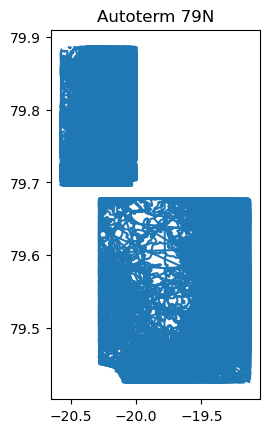

In [37]:
N79_autoterm = pd.merge(N79_autoterm[N79_autoterm['Glacier ID'] == "GID101"], N79_autoterm_lobe2, how='outer')
# Add Month and Year columns to dataframe
N79_autoterm['Year'] = pd.to_datetime(N79_autoterm['Date']).dt.year
N79_autoterm['Month'] = pd.to_datetime(N79_autoterm['Date']).dt.month

N79_autoterm.plot()
plt.title("Autoterm 79N")
N79_autoterm

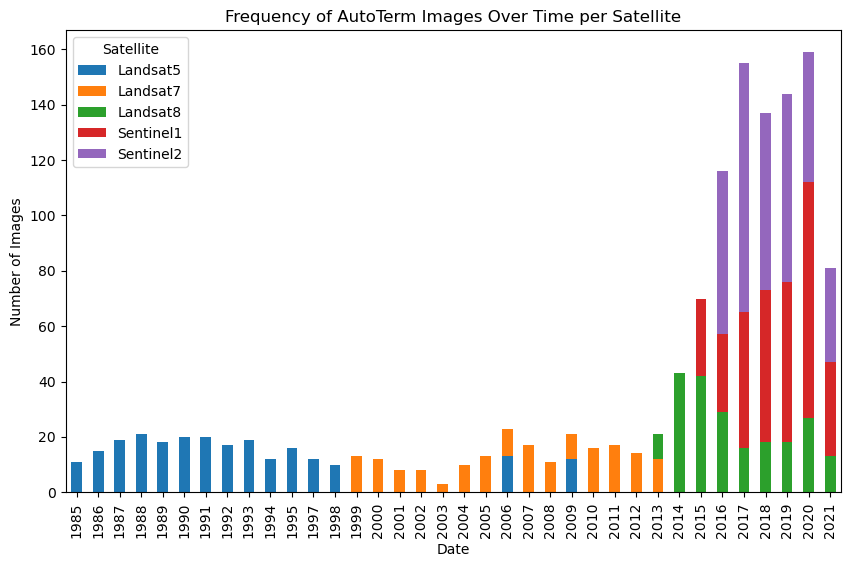

In [6]:
N79_autoterm.groupby(['Year', 'Satellite']).size().unstack().plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Date')
plt.ylabel('Number of Images')
plt.title('Frequency of AutoTerm Images Over Time per Satellite')
plt.show()

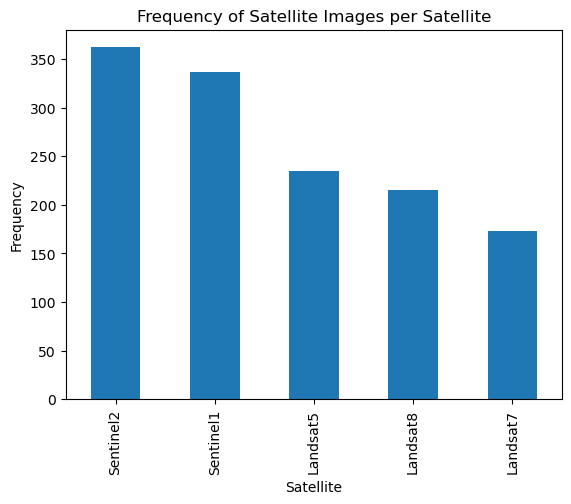

In [7]:
N79_autoterm['Satellite'].value_counts().plot(kind='bar')
plt.xlabel('Satellite')
plt.ylabel('Frequency')
plt.title('Frequency of Satellite Images per Satellite')
plt.show()

## TermPicks

TermPicks data were compiled from a variety of satellites (mostly Landsat) over time.

/var/folders/z2/t78xbk451n74r4q5p4w1zt640000gn/T/ipykernel_32406/526693752.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  N79_termpicks['Date'] = pd.to_datetime(N79_termpicks['Date'], errors='coerce')


,GlacierID,Date,Year,Month,Day,DecDate,QualFlag,Satellite,ImageID,Author,Center_X,Center_Y,geometry
0,100,NaT,NaN,NaN,0,1948.000000,00,Historical Map,1948_AMSC501_ND.tif,Hill,-20.179466,79.804158,"LINESTRING (459531.643 -1003678.379, 459767.84..."
1,100,NaT,NaN,NaN,0,1948.000000,00,Historical Map,1948_AMSC501_ND.tif,Hill,-19.355508,79.662945,"LINESTRING (486245.311 -1008111.245, 486423.85..."
2,100,NaT,NaN,NaN,0,1968.000000,00,Historical Map,txu-pclmaps-oclc-8322829_b_9_1968.jpg,Hill,-20.186165,79.805542,"LINESTRING (459609.429 -1004105.149, 460201.61..."
3,100,NaT,NaN,NaN,0,1968.000000,00,Historical Map,txu-pclmaps-oclc-8322829_b_9_1968.jpg,Hill,-19.311418,79.664464,"LINESTRING (486519.896 -1007905.912, 486900.33..."
4,100,1973-05-19,1973.0,5.0,19,1973.378082,00,Landsat,LM10180011973139FAK02_B7.TIF,Hill,-20.172054,79.834682,"LINESTRING (458308.815 -996969.301, 458623.261..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,101,2017-08-30,2017.0,8.0,30,2017.660274,05,Landsat,LC08_L1TP_007003_20170830_20170915_01_T1,Wood,-19.539504,79.562934,"LINESTRING (489729 -1040320, 489693 -1040290, ..."
248,101,2017-09-04,2017.0,9.0,4,2017.673973,05,Landsat,LC08_L1TP_010002_20170904_20170916_01_T1,PROMICE,-19.574043,79.546235,"LINESTRING (484077.643 -1007816.031, 484215.93..."
249,101,2018-08-30,2018.0,8.0,30,2018.660274,00,Sentinel 2,0,PROMICE,-19.578918,79.538829,"LINESTRING (484132.377 -1007711.675, 484302.18..."
250,101,2019-03-11,2019.0,3.0,11,2019.189041,05,Landsat,"LC08_L1TP_009002_20190311_20190325_01_T1,LC08_...",Wood,-19.541075,79.562580,"LINESTRING (489896 -1040650, 489796 -1040550, ..."


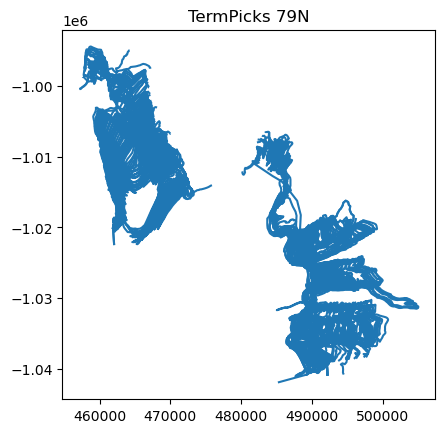

In [9]:
N79_termpicks = termpicks[termpicks['GlacierID'] == 101]
N79_termpicks = pd.merge(N79_termpicks, termpicks[termpicks['GlacierID'] == 100], how='outer')

N79_termpicks['Date'] = pd.to_datetime(N79_termpicks['Date'], errors='coerce')
N79_termpicks['Year'] = N79_termpicks['Date'].dt.year
N79_termpicks['Month'] = N79_termpicks['Date'].dt.month

# Remove outlier termini (3 from Carr that are clearly not 79N but are labeled as such)
# Calculate Q1, Q3, and IQR for Center_X and Center_Y
Q1_x = N79_termpicks['Center_X'].quantile(0.25)
Q3_x = N79_termpicks['Center_X'].quantile(0.75)
IQR_x = Q3_x - Q1_x

Q1_y = N79_termpicks['Center_Y'].quantile(0.25)
Q3_y = N79_termpicks['Center_Y'].quantile(0.75)
IQR_y = Q3_y - Q1_y

# Define outlier bounds
lower_bound_x = Q1_x - 1.5 * IQR_x
upper_bound_x = Q3_x + 1.5 * IQR_x
lower_bound_y = Q1_y - 1.5 * IQR_y
upper_bound_y = Q3_y + 1.5 * IQR_y

# Filter out outliers
N79_termpicks = N79_termpicks[
    (N79_termpicks['Center_X'] >= lower_bound_x) & (N79_termpicks['Center_X'] <= upper_bound_x) &
    (N79_termpicks['Center_Y'] >= lower_bound_y) & (N79_termpicks['Center_Y'] <= upper_bound_y)
]

N79_termpicks.plot()
plt.title("TermPicks 79N")
N79_termpicks

## Compile and plot all data

In [39]:
# Group each dataset by Year and Month and count occurrences
nsidc_counts = N79_nsidc.groupby(['Year', 'Month']).size().rename('NSIDC')
autoterm_counts = N79_autoterm.groupby(['Year', 'Month']).size().rename('AutoTerm')
termpicks_counts = N79_termpicks.groupby(['Year', 'Month']).size().rename('TermPicks')
# sofia_counts = sofia_termini.groupby(['Year', 'Month']).size().rename('Sofia Termini')

# Create a complete index of all Year and Month combinations from 2000 to 2024
all_years_months = pd.MultiIndex.from_product(
    [range(2000, 2025), range(1, 13)], names=["Year", "Month"]
)

# Reindex each dataset to include all Year and Month combinations, filling missing values with 0
nsidc_counts = nsidc_counts.reindex(all_years_months, fill_value=0)
autoterm_counts = autoterm_counts.reindex(all_years_months, fill_value=0)
termpicks_counts = termpicks_counts.reindex(all_years_months, fill_value=0)
# sofia_counts = sofia_counts.reindex(all_years_months, fill_value=0)

# Combine all counts into a single DataFrame
# compiled_data = pd.concat([nsidc_counts, autoterm_counts, termpicks_counts], axis=1).reset_index()
compiled_data = pd.concat([nsidc_counts, termpicks_counts], axis=1).reset_index()

# Fill NaN values with 0 (indicating no data for that dataset in a given month)
compiled_data.fillna(0, inplace=True)

# Convert counts to integers
compiled_data[['NSIDC', 'TermPicks']] = compiled_data[['NSIDC', 'TermPicks']].astype(int)
compiled_data.set_index(['Year', 'Month'], inplace=True)

compiled_data

NSIDC  TermPicks
Year Month                  
2000 1          0          0
     2          0          0
     3          0          0
     4          0          0
     5          0          0
...           ...        ...
2024 8          0          0
     9          0          0
     10         0          0
     11         0          0
     12         0          0

[300 rows x 2 columns]

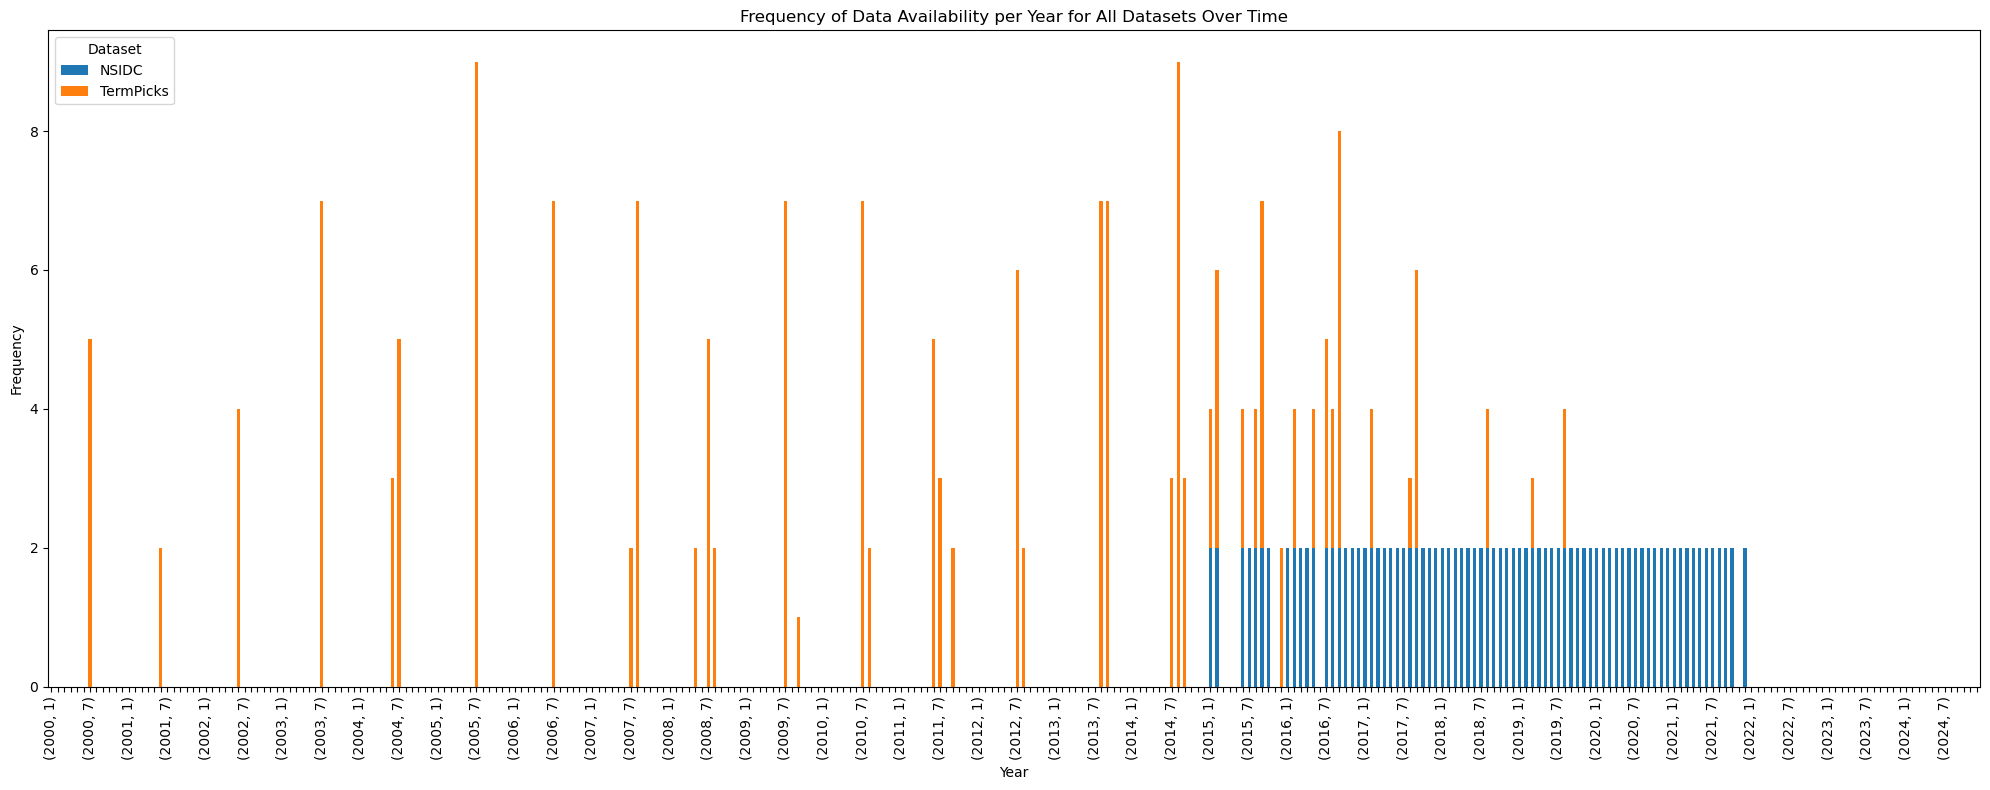

In [46]:
# Convert to DataFrame
ax = compiled_data.plot(kind='bar', stacked=True, figsize=(20, 8))

for i, t in enumerate(ax.get_xticklabels()):
    if (i % 6) != 0:
        t.set_visible(False)
        plt.xlabel('Year')
        
plt.ylabel('Frequency')
plt.title('Frequency of Data Availability per Year for All Datasets Over Time')
plt.legend(title='Dataset', loc='upper left')
plt.tight_layout()

plt.savefig('79N_terminus_data_availability.png', dpi=300)
plt.show()

<Axes: >

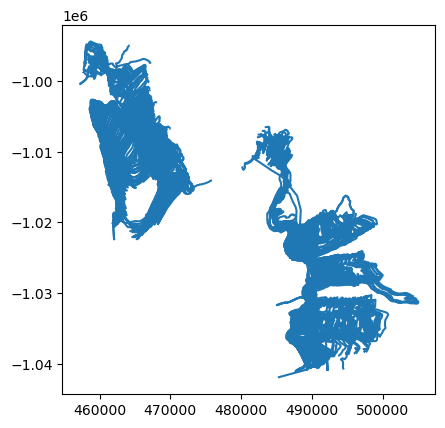

In [45]:
compiled_data_plot = pd.merge(N79_nsidc, N79_termpicks, how='outer')
compiled_data_plot.plot()

In [41]:
print(compiled_data.size)

600
